In [1]:
import os
import sys

REPO_URL = "https://github.com/gCorona45/Corona_Sechi.git"
REPO_DIR = "/content/Corona_Sechi"

# Detectar si estamos en Google Colab
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    # Clonar el repositorio si no está presente
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}
        print("Repositorio clonado correctamente.")

    # Navegar a la carpeta del experimento
    os.chdir(os.path.join(REPO_DIR, "k_brazos"))

    # Añadir src al path
    sys.path.append(os.path.join(REPO_DIR, "k_brazos", "src"))

    # Instalar dependencias
    !pip install -q tqdm matplotlib seaborn
    print(f"Directorio de trabajo: {os.getcwd()}")
else:
    # Ejecución local: src ya está accesible
    sys.path.append(os.path.join(os.getcwd(), 'src'))

Directorio de trabajo: /content/Corona_Sechi/k_brazos


In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- CONFIGURACIÓN DEL PATH ---
# Permite importar los módulos desde la carpeta 'src' estando dentro de 'test'
current_dir = os.getcwd()

# Subimos un nivel desde la carpeta 'test' para llegar a la raíz del proyecto
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

# Ahora bajamos a la carpeta 'src'
src_path = os.path.join(parent_dir, 'src')

if src_path not in sys.path:
    sys.path.append(src_path)
    print(f"Ruta 'src' añadida correctamente: {src_path}")

# --- IMPORTACIONES ---
from utils import set_global_seed
from armnormal import ArmNormal
from algorithms import EpsilonGreedy, UCB1

# Configuración de la semilla global para garantizar la reproducibilidad
SEED = 2024
set_global_seed(SEED)

Ruta 'src' añadida correctamente: /content/Corona_Sechi/src
Configurando semilla global (Global Seed): 2024
GPU no detectada. Usando CPU.


## 1. Experimento Avanzado: Análisis de Escalabilidad (La Maldición de la Dimensionalidad)

En los experimentos anteriores hemos evaluado el rendimiento de los algoritmos en entornos con un espacio de acciones reducido ($k=5$). Sin embargo, en aplicaciones reales de Inteligencia Artificial (por ejemplo, recomendación de productos en un catálogo masivo), el número de opciones $k$ puede ser enorme.

### Objetivo del Estudio
El objetivo es analizar cómo se degrada el rendimiento (medido a través del **Regret Acumulado Final**) a medida que aumenta el número de brazos $k \in \{5, 10, 25, 50, 100\}$.

### Hipótesis Teórica
- **Epsilon-Greedy:** Se espera que sufra significativamente. Al tener una exploración ciega (uniforme), la probabilidad de encontrar el brazo óptimo por puro azar disminuye a $\frac{\epsilon}{k}$.
- **UCB1:** Al estar fundamentado en los límites de Hoeffding, garantiza encontrar el óptimo asintóticamente. Sin embargo, requiere una fase de inicialización donde debe probar **todos** los brazos al menos una vez. Para un $k$ muy grande, esta fase de exploración forzada dominará los primeros pasos, pero a largo plazo debería escalar mejor que las estrategias puramente codiciosas.

<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:63: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_6694/2650819645.py:63: SyntaxWarning: invalid escape sequence '\e'
  label="Epsilon-Greedy ($\epsilon=0.1$)", color="coral")
Evaluando diferentes valores de k: 100%|██████████| 5/5 [12:16<00:00, 147.24s/it]


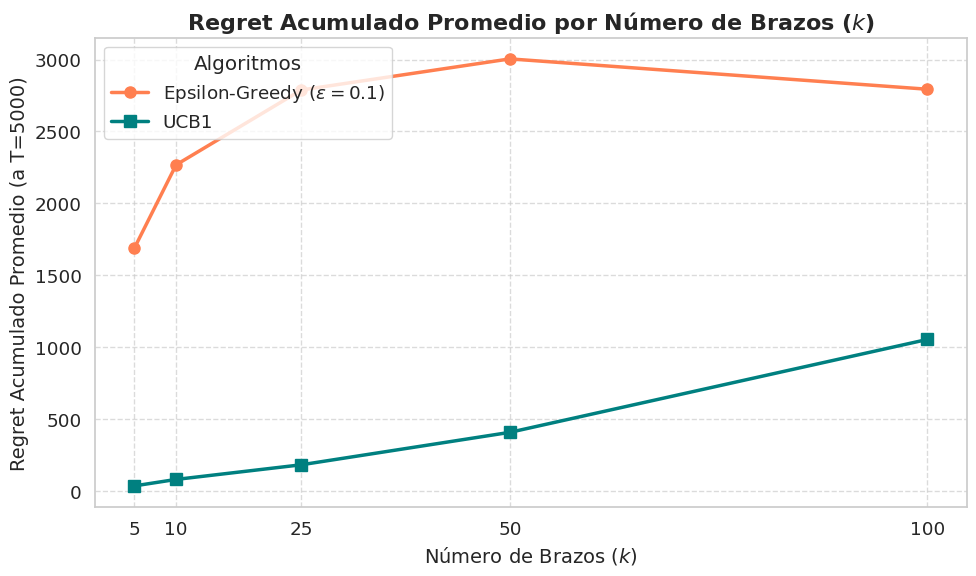

In [3]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# --- PARÁMETROS DEL EXPERIMENTO ---
K_VALUES = [5, 10, 25, 50, 100]  # Valores de k (número de brazos)
N_STEPS = 5000  # Número de pasos por simulación
N_RUNS = 500  # Número de simulaciones por cada valor de k

# Lista para guardar los resultados de cada simulación
resultados = []

for k in tqdm(K_VALUES, desc="Evaluando diferentes valores de k"):
    # Generación del entorno con k brazos
    entorno_brazos = ArmNormal.generate_arms(k=k)
    medias_brazos = [brazo.get_expected_value() for brazo in entorno_brazos]
    valor_esperado_optimo = max(medias_brazos)

    for run in range(N_RUNS):
        # Instanciar los algoritmos
        algo_eps = EpsilonGreedy(k=k, epsilon=0.1)
        algo_ucb = UCB1(k=k)

        regret_eps = 0.0
        regret_ucb = 0.0

        for t in range(N_STEPS):
            # --- Epsilon-Greedy ---
            brazo_eps = algo_eps.select_arm()
            recompensa_eps = entorno_brazos[brazo_eps].pull()
            algo_eps.update(brazo_eps, recompensa_eps)
            regret_eps += (valor_esperado_optimo - medias_brazos[brazo_eps])

            # --- UCB1 ---
            brazo_ucb = algo_ucb.select_arm()
            recompensa_ucb = entorno_brazos[brazo_ucb].pull()
            algo_ucb.update(brazo_ucb, recompensa_ucb)
            regret_ucb += (valor_esperado_optimo - medias_brazos[brazo_ucb])

        # Guardar los resultados de esta simulación
        resultados.append({
            "k": k,
            "regret_eps": regret_eps,
            "regret_ucb": regret_ucb
        })

# Calcular el regret promedio para cada valor de k
regret_promedio_eps = []
regret_promedio_ucb = []

for k in K_VALUES:
    regrets_eps = [resultado["regret_eps"] for resultado in resultados if resultado["k"] == k]
    regrets_ucb = [resultado["regret_ucb"] for resultado in resultados if resultado["k"] == k]
    regret_promedio_eps.append(np.mean(regrets_eps))
    regret_promedio_ucb.append(np.mean(regrets_ucb))

# --- VISUALIZACIÓN ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.figure(figsize=(10, 6))

plt.plot(K_VALUES, regret_promedio_eps, marker='o', markersize=8, linewidth=2.5,
         label="Epsilon-Greedy ($\epsilon=0.1$)", color="coral")
plt.plot(K_VALUES, regret_promedio_ucb, marker='s', markersize=8, linewidth=2.5,
         label="UCB1", color="teal")

plt.title("Regret Acumulado Promedio por Número de Brazos ($k$)", fontsize=16, fontweight='bold')
plt.xlabel("Número de Brazos ($k$)", fontsize=14)
plt.ylabel(f"Regret Acumulado Promedio (a T={N_STEPS})", fontsize=14)

plt.xticks(K_VALUES)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(title='Algoritmos', loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## 2. Análisis Crítico: Escalabilidad de Epsilon-Greedy vs UCB1

La evaluación de la escalabilidad dimensional revela un comportamiento empírico consistente con las predicciones teóricas: a medida que crece el espacio de acciones, **UCB1 mantiene un rendimiento marcadamente superior al de Epsilon-Greedy**, y la brecha entre ambos se amplía de forma pronunciada.

### A. Comportamiento de Epsilon-Greedy
Epsilon-Greedy ($\epsilon=0.1$) sufre un deterioro severo ante la expansión del espacio de acciones. Con $k=5$, su regret acumulado promedio se sitúa ya en $\approx 1700$, y se estabiliza en torno a $\approx 3000$ para $k \geq 25$. Este comportamiento responde a la naturaleza de su mecanismo de exploración uniforme: la probabilidad de seleccionar el brazo óptimo por azar es $\frac{\epsilon}{k}$, que para $k=100$ se reduce a un $0.1\%$. El $10\%$ de las iteraciones dedicadas a exploración se reparten equitativamente entre todos los brazos, un coste que crece linealmente con $k$ y que resulta especialmente ineficiente cuando la mayoría de los brazos son claramente subóptimos.

### B. Comportamiento de UCB1
UCB1 escala de forma notablemente más contenida: desde un regret de $\approx 60$ con $k=5$ hasta $\approx 1050$ con $k=100$. Su exploración dirigida por límites de confianza concentra las muestras en los brazos con mayor incertidumbre y descarta rápidamente los claramente inferiores. Si bien requiere una fase de inicialización obligatoria (probar cada brazo al menos una vez), esta penalización resulta marginal frente al coste sostenido de la exploración ciega de Epsilon-Greedy. La tendencia de su curva confirma el crecimiento sub-lineal predicho por la cota de Lai y Robbins.

### C. Implicaciones Metodológicas
El estudio confirma que, en entornos estocásticos Normales con varianza homogénea, UCB1 mantiene su superioridad teórica también en la práctica:
1. **Para catálogos reducidos ($k \leq 10$):** La ventaja de UCB1 ya es sustancial (regret inferior en un orden de magnitud), pero ambos algoritmos son operacionalmente viables.
2. **Para catálogos masivos ($k \geq 50$):** Epsilon-Greedy se vuelve impracticable. Su regret se estanca en valores elevados independientemente de $k$, mientras que UCB1 sigue ofreciendo una trayectoria de regret manejable.
3. **Validación de la exploración adaptativa:** Este resultado empírico valida que los métodos con exploración dirigida por incertidumbre son imprescindibles en escenarios de alta dimensionalidad, donde la exploración uniforme desperdicia la mayor parte de su presupuesto en brazos irrelevantes.

In [4]:
import numpy as np
from tqdm import tqdm

print("Iniciando análisis de escalabilidad con generate_arms() (Distribución Normal)...")

# --- PARÁMETROS DEL EXPERIMENTO ---
K_VALUES = [5, 10, 25, 50, 100]
N_STEPS = 15000
N_RUNS = 500

final_regrets_eps = []
final_regrets_ucb = []

for k in tqdm(K_VALUES, desc="Evaluando diferentes tamaños de k"):

    # 1. Generación del Entorno usando el Factory Method de la clase Normal
    # Nota: Si tu método generate_arms permite rangos (ej. mu_min, mu_max),
    # puedes añadirlos. Si no, déjalo solo con (k=k).
    entorno_brazos = ArmNormal.generate_arms(k=k, mu_min=1.0, mu_max=30.0,sigma_min=1.0, sigma_max=5.0)

    # Extraemos las medias esperadas reales para calcular el Regret teórico
    arm_means = [brazo.get_expected_value() for brazo in entorno_brazos]
    optimal_expected_value = max(arm_means)

    # Acumuladores de regret total para este valor de k
    regret_eps_k = 0.0
    regret_ucb_k = 0.0

    # 2. Bucle de Simulaciones (Monte Carlo)
    for run in range(N_RUNS):

        # Instanciar algoritmos (se reinician en cada run)
        algo_eps = EpsilonGreedy(k=k, epsilon=0.1)
        algo_ucb = UCB1(k=k)

        run_regret_eps = 0.0
        run_regret_ucb = 0.0

        # 3. Bucle Temporal (Horizonte)
        for t in range(N_STEPS):

            # --- Ejecución Epsilon-Greedy ---
            arm_eps = algo_eps.select_arm()
            reward_eps = entorno_brazos[arm_eps].pull()
            algo_eps.update(arm_eps, reward_eps)

            # Cálculo del regret basado en el valor esperado
            run_regret_eps += (optimal_expected_value - arm_means[arm_eps])

            # --- Ejecución UCB1 ---
            arm_ucb = algo_ucb.select_arm()
            reward_ucb = entorno_brazos[arm_ucb].pull()
            algo_ucb.update(arm_ucb, reward_ucb)

            # Cálculo del regret basado en el valor esperado
            run_regret_ucb += (optimal_expected_value - arm_means[arm_ucb])

        # Acumular el regret total de esta simulación específica
        regret_eps_k += run_regret_eps
        regret_ucb_k += run_regret_ucb

    # Calcular la media sobre todas las runs para el valor actual de k
    final_regrets_eps.append(regret_eps_k / N_RUNS)
    final_regrets_ucb.append(regret_ucb_k / N_RUNS)

print("\nAnálisis de escalabilidad completado.")

Iniciando análisis de escalabilidad con generate_arms() (Distribución Normal)...


Evaluando diferentes tamaños de k: 100%|██████████| 5/5 [37:13<00:00, 446.72s/it]


Análisis de escalabilidad completado.


Iniciando análisis de escalabilidad con generate_arms() (Distribución Normal)...


Evaluando diferentes tamaños de k:  60%|██████    | 3/5 [20:25<13:44, 412.06s/it]

<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_6694/3949904846.py:6: SyntaxWarning: invalid escape sequence '\e'
  label="Epsilon-Greedy ($\epsilon=0.1$)", color="coral")


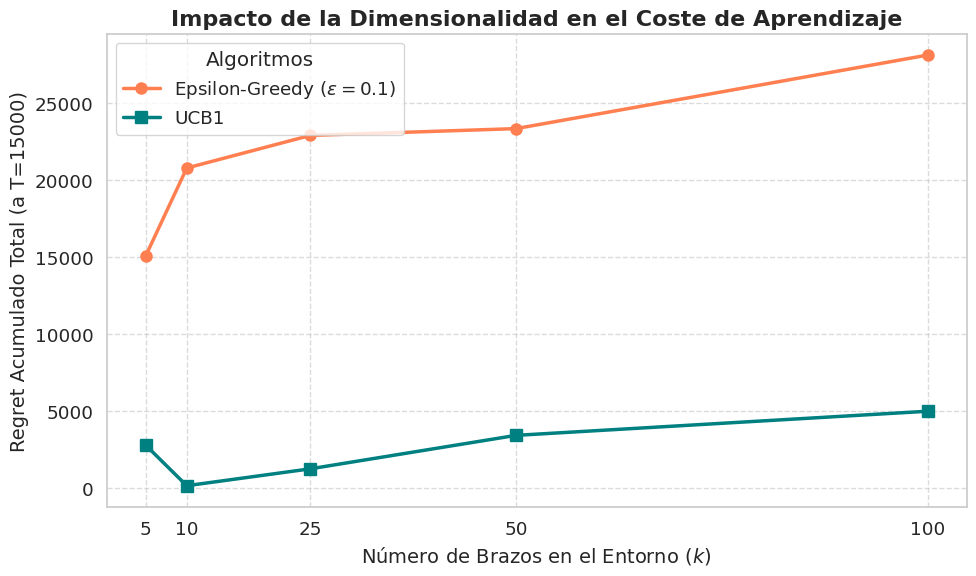

In [5]:

# --- VISUALIZACIÓN DE LA ESCALABILIDAD ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.figure(figsize=(10, 6))

plt.plot(K_VALUES, final_regrets_eps, marker='o', markersize=8, linewidth=2.5,
         label="Epsilon-Greedy ($\epsilon=0.1$)", color="coral")
plt.plot(K_VALUES, final_regrets_ucb, marker='s', markersize=8, linewidth=2.5,
         label="UCB1", color="teal")

plt.title("Impacto de la Dimensionalidad en el Coste de Aprendizaje", fontsize=16, fontweight='bold')
plt.xlabel("Número de Brazos en el Entorno ($k$)", fontsize=14)
plt.ylabel(f"Regret Acumulado Total (a T={N_STEPS})", fontsize=14)

plt.xticks(K_VALUES)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(title='Algoritmos', loc='upper left', frameon=True)
plt.tight_layout()
plt.show()